   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64
MAE : 6286.453830757745
MSE : 49830096.855908394
R2 Score : 0.9024461774180497


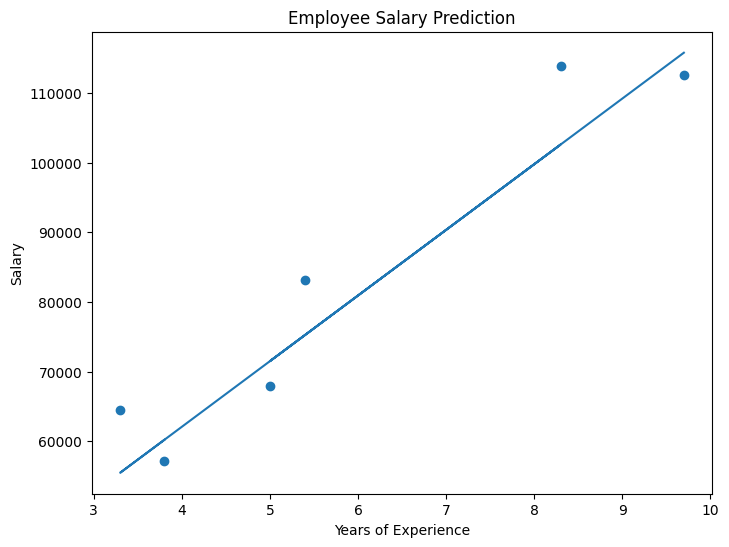

Predicted Salary for 5 years of experience: ₹71,499.28


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("/content/Salary_dataset.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())
X = df[['YearsExperience']]
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Employee Salary Prediction")
plt.show()
with open("salary_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("salary_model.pkl", "rb") as f:
    model = pickle.load(f)
new_data = pd.DataFrame({
    'YearsExperience': [5]
})
prediction = model.predict(new_data)
print(f"Predicted Salary for 5 years of experience: ₹{prediction[0]:,.2f}")
